Importing Packages

In [ ]:
import sys
import os

notebook_dir = os.path.abspath('')
project_root = os.path.dirname(notebook_dir)
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

from src.data_processing import load_and_clean_data

print("Imports successful")

✅ Imports successful


Training Datsets

In [ ]:
df = load_and_clean_data('../data/diabetes.csv')
X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training samples: {X_train_scaled.shape[0]}")
print(f"Test samples: {X_test_scaled.shape[0]}")

Training samples: 614
Test samples: 154


Processing Models

In [ ]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(eval_metric='logloss', random_state=42)
}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    print(f"Trained: {name}")

✅ Trained: Logistic Regression
✅ Trained: Random Forest
✅ Trained: XGBoost


Processed Output

In [10]:
results_list = []

for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    
    results_list.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall (Sensitivity)': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba),
        'False Negatives': fn,
        'False Positives': fp
    })

results_df = pd.DataFrame(results_list)
results_df = results_df.round(3)
print("Model Comparison (Focus on Recall / Sensitivity):")
print(results_df.to_string(index=False))

Model Comparison (Focus on Recall / Sensitivity):
              Model  Accuracy  Precision  Recall (Sensitivity)  F1-Score  ROC-AUC  False Negatives  False Positives
Logistic Regression     0.708      0.600                 0.500     0.545    0.813               27               18
      Random Forest     0.779      0.717                 0.611     0.660    0.818               21               13
            XGBoost     0.760      0.673                 0.611     0.641    0.808               21               16


In [ ]:
best_idx = results_df['Recall (Sensitivity)'].idxmax()
best_model_name = results_df.loc[best_idx, 'Model']
best_model = models[best_model_name]

print(f"🏆 Best model for clinical use: {best_model_name}")
print(f"Recall: {results_df.loc[best_idx, 'Recall (Sensitivity)']}")

🏆 Best model for clinical use: Random Forest
Recall: 0.611


Importing processed output

In [ ]:
import os
import joblib

os.makedirs('../models', exist_ok=True)

joblib.dump(best_model, '../models/diabetes_model.pkl')

# Save scaler
joblib.dump(scaler, '../models/scaler.pkl')

print("Model saved as '../models/diabetes_model.pkl'")
print("Scaler saved as '../models/scaler.pkl'")

✅ Model saved as '../models/diabetes_model.pkl'
✅ Scaler saved as '../models/scaler.pkl'


Using shap for the plotting

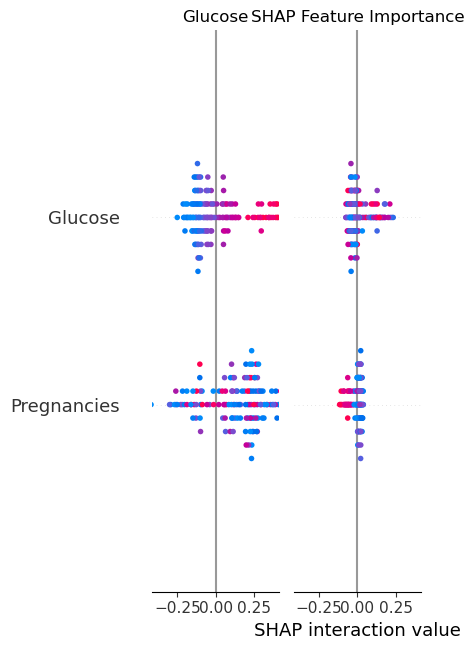

In [ ]:
import shap

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test_scaled)

shap.summary_plot(shap_values, X_test_scaled, feature_names=X.columns, show=False)
plt.title('SHAP Feature Importance')
plt.tight_layout()
plt.savefig('../reports/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()